In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import KFold
from sklearn.datasets import load_wine
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict
from sklearn.decomposition import PCA
from sklearn.base import clone

In [5]:
def resultados_a_df(nombres, datos):
    """Arma un DataFrame comparativo (mínimo, máximo, media y varianza) a partir
    de los resultados de evaluar_kfold para uno o más modelos/ensambles."""

    filas = []
    for nombre, resultados in zip(nombres, datos):
        aciertos = np.array(resultados) * 100
        filas.append({
            'Modelo': nombre,
            'Particiones': len(resultados),
            'Mínimo (%)': aciertos.min(),
            'Máximo (%)': aciertos.max(),
            'Media (%)': aciertos.mean(),
            'Varianza': np.var(resultados),
        })

    df = pd.DataFrame(filas).set_index('Modelo')
    df = df.sort_values('Media (%)', ascending=False)

    return (
        df.style
        .format({
            'Mínimo (%)': '{:.2f}',
            'Máximo (%)': '{:.2f}',
            'Media (%)': '{:.2f}',
            'Varianza': '{:.6f}',
        })
        .highlight_max(subset=['Media (%)'], color='#c6f6d5')
        .highlight_min(subset=['Varianza'], color='#bee3f8')
    )

In [6]:
def evaluar_kfold(k, modelo):

    kf = KFold(n_splits=k, shuffle=True, random_state=2077)

    resultados = []

    for train, test in kf.split(X):

        X_train = X[train]
        y_train = y[train]

        X_test = X[test]
        y_test = y[test]

    
        modelo.fit(X_train, y_train)

        aciertos = modelo.score(X_test, y_test)

        resultados.append(aciertos)

    return resultados

In [18]:
def graficar(nombres, resultados, titulo='Aciertos por modelo en KFold', xlabel='Modelos', rotation=0):

    plt.figure(figsize=(10, 6))

    for i in range(len(nombres)):
        aciertos = np.array(resultados[i]) * 100
        x = np.full(len(aciertos), i)

        plt.scatter(x, aciertos)

    plt.xticks(range(len(nombres)), nombres, rotation=rotation, ha='right' if rotation else 'center')
    plt.xlabel(xlabel)
    plt.ylabel('Porcentaje de aciertos')

    plt.title(titulo)
    plt.grid(axis='y')

    plt.show()

def graficar_k10(nombres, resultados, titulo='Aciertos por modelo en KFold', xlabel='Modelos', rotation=0):
    plt.figure(figsize=(10, 6))

    for i in range(len(nombres)):
        aciertos = np.array(resultados[i]) * 100
        
        # Generamos un pequeño desvío horizontal aleatorio para separar los puntos
        jitter = np.random.normal(0, 0.06, size=len(aciertos))
        x = np.full(len(aciertos), i) + jitter

        # Agregamos alpha=0.7 para darle transparencia a los puntos
        plt.scatter(x, aciertos, alpha=0.7, edgecolors='black', linewidth=0.5)

    plt.xticks(range(len(nombres)), nombres, rotation=rotation, ha='right' if rotation else 'center')
    plt.xlabel(xlabel)
    plt.ylabel('Porcentaje de aciertos')

    plt.title(titulo)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

## Ejercicio 1

La biblioteca dispone de la función `train_test_split`, que permite generar una partición de entrenamiento y prueba, y `KFold`, que genera varias particiones de validación cruzada.

Estudie el uso de estas funciones y utilícelas para generar particiones a partir del conjunto de datos **Digits**, que en Scikit-learn puede cargarse usando la función `load_digits` del módulo `datasets`.

Mediante `MLPClassifier` construya un perceptrón multicapa adecuado para este conjunto de datos y analice su desempeño considerando:

- 1 única partición de datos generada mediante `train_test_split`,
- 5 particiones generadas mediante `KFold`,
- 10 particiones generadas mediante `KFold`.

Para el análisis tenga en cuenta la media y la varianza de la tasa de acierto obtenida en cada partición.

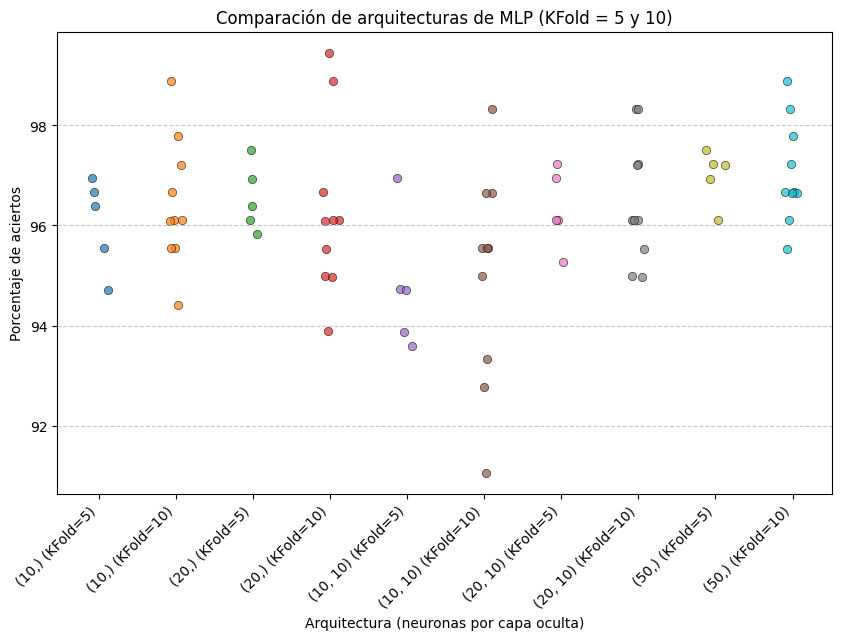

Arquitectura elegida: (50,)


In [19]:
digits = load_digits()

X = digits.data
y = digits.target

nombre = 'Perceptrón multicapa'

arquitecturas = [(10,), (20,), (10, 10), (20, 10), (50,)]
ks_arq = [5, 10]

filas_arq = []
etiquetas_arq = []
datos_arq = []
resultados_por_arq = {arq: [] for arq in arquitecturas}

for arq in arquitecturas:
    for k in ks_arq:
        modelo_arq = MLPClassifier(hidden_layer_sizes=arq, max_iter=1000, random_state=2077)
        resultados = evaluar_kfold(k, modelo_arq)
        aciertos = np.array(resultados) * 100

        etiquetas_arq.append(f'{arq} (KFold={k})')
        datos_arq.append(resultados)
        resultados_por_arq[arq].extend(resultados)

        filas_arq.append({
            'Arquitectura': str(arq),
            'KFold': k,
            'Media (%)': aciertos.mean(),
            'Varianza': np.var(resultados),
        })

tabla_arquitecturas = (
    pd.DataFrame(filas_arq)
    .sort_values(['Arquitectura', 'KFold'])
    .set_index(['Arquitectura', 'KFold'])
    .style.format({'Media (%)': '{:.2f}', 'Varianza': '{:.6f}'})
)
display(tabla_arquitecturas)

graficar_k10(etiquetas_arq, datos_arq, titulo='Comparación de arquitecturas de MLP (KFold = 5 y 10)', xlabel='Arquitectura (neuronas por capa oculta)', rotation=45)

medias_por_arq = {arq: np.mean(resultados) for arq, resultados in resultados_por_arq.items()}
mejor_arquitectura = max(medias_por_arq, key=medias_por_arq.get)

print(f'Arquitectura elegida: {mejor_arquitectura}')


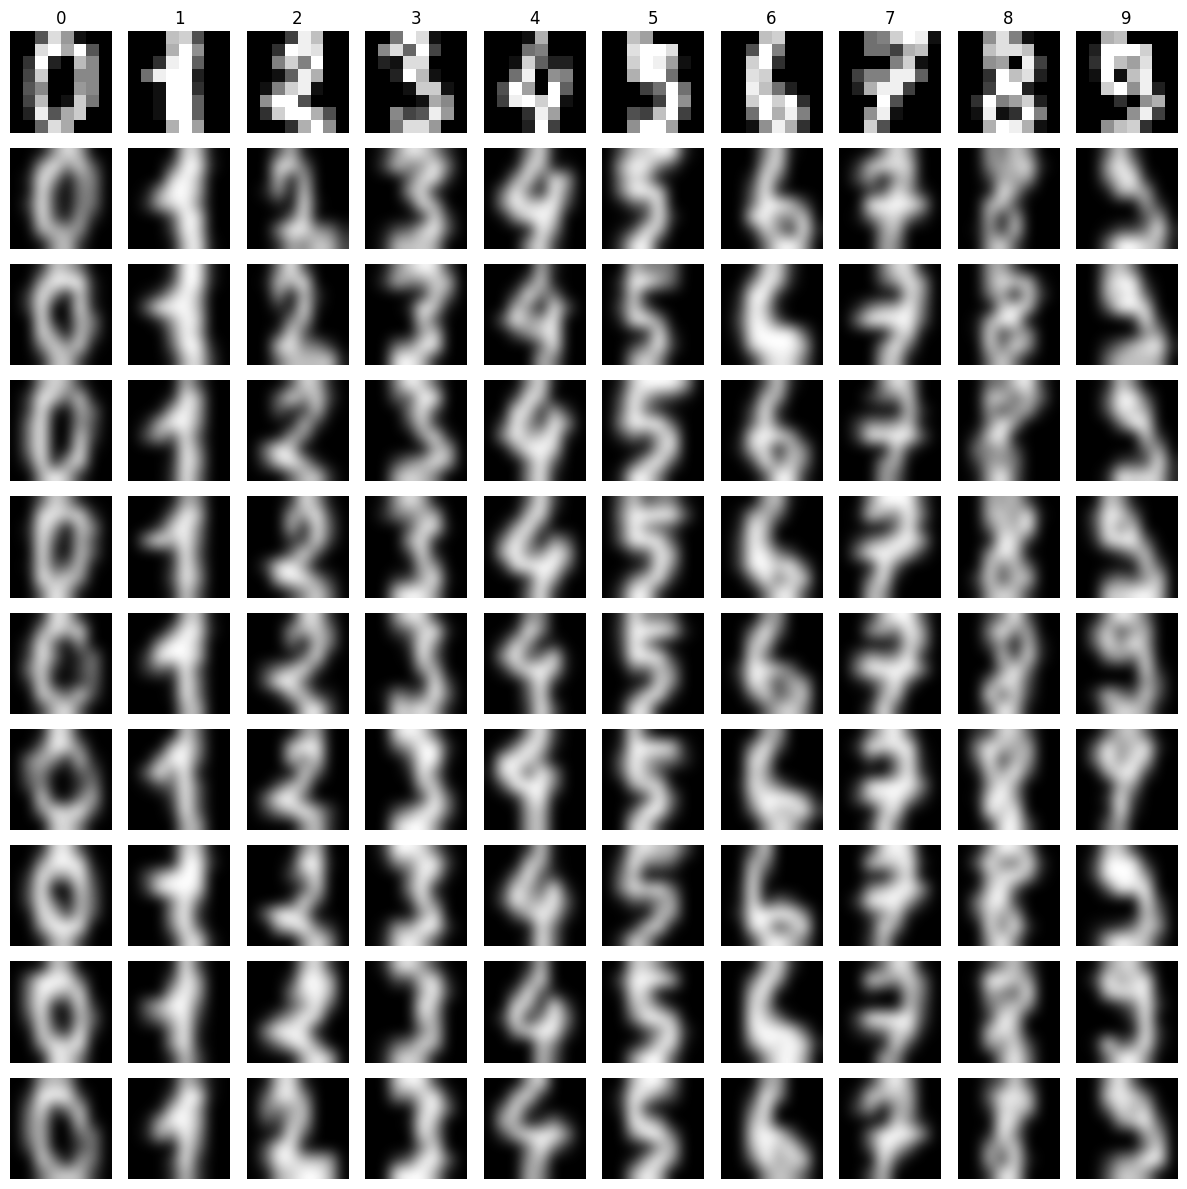

In [9]:
n_ejemplos = 10

fig, axes = plt.subplots(n_ejemplos, 10, figsize=(12, 12))

for digito in range(10):
    indices = np.where(y == digito)[0][:n_ejemplos]
    for fila, idx in enumerate(indices):
        ax = axes[fila, digito]
        interpolacion = 'nearest' if fila == 0 else 'bicubic'
        ax.imshow(digits.images[idx], cmap='gray', interpolation=interpolacion)
        ax.axis('off')
        if fila == 0:
            ax.set_title(f'{digito}')

plt.tight_layout()
plt.show()



,Particiones,Mínimo (%),Máximo (%),Media (%),Varianza
Modelo,,,,,
Partición 20%,1,97.78,97.78,97.78,0.000000
KFold = 10,10,95.53,98.89,97.05,0.000094
KFold = 5,5,96.10,97.50,96.99,0.000023


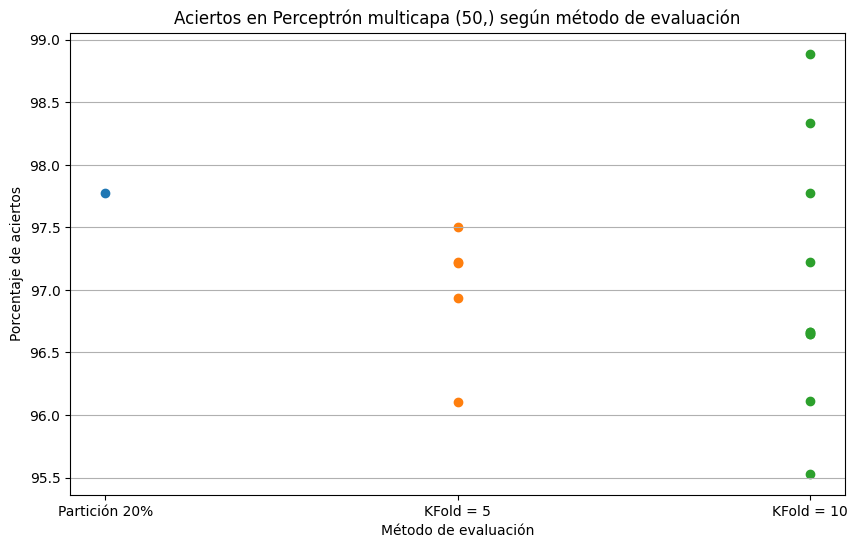

In [10]:
# Partición 80/20 con train_test_split
modelo_split = MLPClassifier(hidden_layer_sizes=mejor_arquitectura, max_iter=1000, random_state=2077)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2077)

modelo_split.fit(X_train, y_train)
aciertos_split = modelo_split.score(X_test, y_test)

# Particiones con KFold (5 y 10)
ks = [5, 10]

datos_kfold = []
for k in ks:
    modelo_kfold = MLPClassifier(hidden_layer_sizes=mejor_arquitectura, max_iter=1000, random_state=2077)
    datos_kfold.append(evaluar_kfold(k, modelo_kfold))

etiquetas = ['Partición 20%', 'KFold = 5', 'KFold = 10']
datos = [[aciertos_split]] + datos_kfold

tabla_ex1 = resultados_a_df(etiquetas, datos)
display(tabla_ex1)

graficar(etiquetas, datos, titulo=f'Aciertos en {nombre} {mejor_arquitectura} según método de evaluación', xlabel='Método de evaluación')

## Análisis de resultados – Ejercicio 1

Para elegir una arquitectura "adecuada" de perceptrón multicapa, se compararon cinco configuraciones candidatas ((10,), (20,), (10,10), (20,10) y (50,)), evaluando cada una con KFold=5 y KFold=10 y combinando los aciertos de ambos esquemas. La arquitectura de una sola capa oculta con 50 neuronas, **(50,)**, obtuvo la mejor media de aciertos (**97,03%**) junto con la menor varianza (**0,000070**) de todas las candidatas, por lo que fue la elegida para el resto del ejercicio.

Con esa arquitectura se evaluó el desempeño considerando una partición del 20% y los métodos KFold con 5 y 10 particiones.

Con la partición del 20%, se obtuvo un porcentaje de aciertos del **97,78%** sobre el conjunto de prueba.

Al utilizar **KFold con 5 particiones**, los porcentajes de aciertos estuvieron entre **96,10% y 97,50%**, obteniendo una media de **96,99%** y una varianza de **0,000023**.

Por otro lado, con **KFold de 10 particiones**, los resultados estuvieron entre **95,53% y 98,89%**, con una media de **97,05%** y una varianza de **0,000094**.

Comparando los resultados, los tres métodos de evaluación arrojaron medias muy parecidas entre sí (entre 96,99% y 97,78%), y KFold=5 volvió a ser el más estable de los dos esquemas de validación cruzada, con una varianza notablemente menor que KFold=10.

En conclusión, elegir la arquitectura por comparación —evaluándola con ambos esquemas de KFold en lugar de uno solo— en lugar de fijarla a priori, permitió obtener un perceptrón multicapa con mejor rendimiento promedio (~97%) y mucha menor variabilidad entre particiones que la arquitectura (10,10) usada originalmente, lo que confirma la importancia de justificar la arquitectura antes de comparar métodos de evaluación.


## Ejercicio 2

Mediante el esquema de cinco particiones generadas con `KFold`, compare el desempeño del perceptrón multicapa con los siguientes clasificadores:

- Naive Bayes
- Análisis discriminante lineal
- K vecinos más cercanos
- Árbol de decisión
- Máquina de soporte vectorial

,Particiones,Mínimo (%),Máximo (%),Media (%),Varianza
Modelo,,,,,
Máquina de soporte vectorial (MSV),5,98.05,99.72,98.78,0.000033
K vecinos mas cercanos (KNN),5,98.05,99.44,98.61,0.000025
Perceptrón multicapa,5,96.10,97.50,96.99,0.000023
Análisis discriminante lineal (ADL),5,93.61,96.38,95.05,0.000122
Árbol de decision,5,85.00,87.22,86.03,0.000094
Naive Bayes,5,77.99,85.83,83.08,0.000768


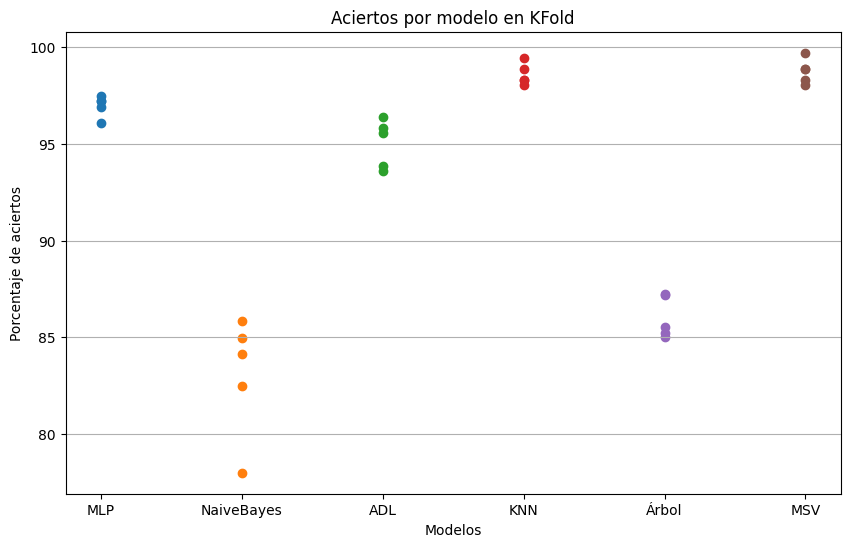

In [11]:
nombres = ['Perceptrón multicapa',
           'Naive Bayes', 
           'Análisis discriminante lineal (ADL)', 
           'K vecinos mas cercanos (KNN)', 
           'Árbol de decision', 
           'Máquina de soporte vectorial (MSV)']

modelos = [MLPClassifier(hidden_layer_sizes=mejor_arquitectura, max_iter=1000, random_state=2077),
           GaussianNB(), 
           LinearDiscriminantAnalysis(), 
           KNeighborsClassifier(), 
           DecisionTreeClassifier(random_state=2077), 
           SVC(random_state=2077)]

etiquetas = ['MLP', 'NaiveBayes', 'ADL', 'KNN', 'Árbol', 'MSV']

datos = []
for i in range(len(nombres)):
    resultados = evaluar_kfold(5, modelos[i])
    datos.append(resultados)

tabla_ex2 = resultados_a_df(nombres, datos)
display(tabla_ex2)

graficar(etiquetas, datos)


La media y la varianza dicen *cuánto* se equivoca cada modelo, pero no *en qué*. Las matrices de confusión —calculadas con `cross_val_predict` sobre las mismas particiones— muestran específicamente qué dígitos confunde cada clasificador: las filas son la clase real, las columnas la clase predicha, y la diagonal son los aciertos.

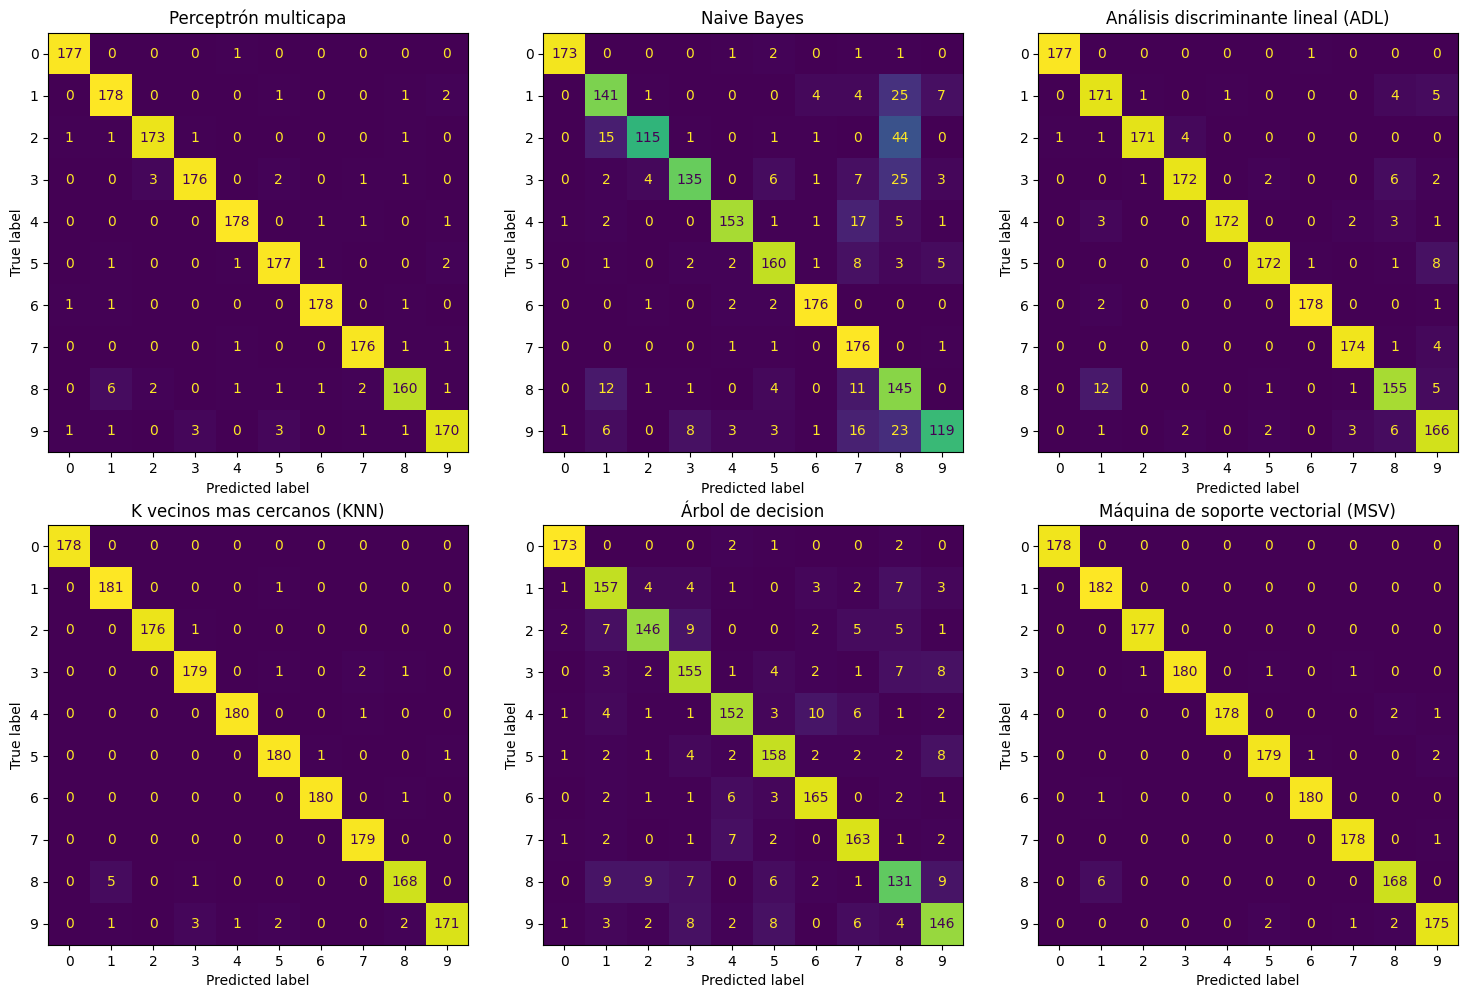

In [12]:
kf_ex2 = KFold(n_splits=5, shuffle=True, random_state=2077)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, nombre_modelo, modelo in zip(axes.ravel(), nombres, modelos):
    predicciones = cross_val_predict(modelo, X, y, cv=kf_ex2)
    matriz = confusion_matrix(y, predicciones)
    ConfusionMatrixDisplay(matriz, display_labels=digits.target_names).plot(ax=ax, colorbar=False)
    ax.set_title(nombre_modelo)

plt.tight_layout()
plt.show()

Para visualizar *por qué* cada algoritmo comete ese tipo de errores, se proyectan los datos a 2 dimensiones con PCA y se reentrena una copia de cada modelo solo sobre esas 2 componentes, para poder dibujar su frontera de decisión. Es una simplificación ilustrativa: al reducir de 64 a 2 dimensiones se pierde información, por lo que los errores puntuales de este gráfico no necesariamente coinciden con los de la matriz de confusión (que usa las 64 dimensiones reales) — lo que hay que observar es la **forma** de la frontera de cada modelo, no el detalle exacto de qué punto cae dónde.


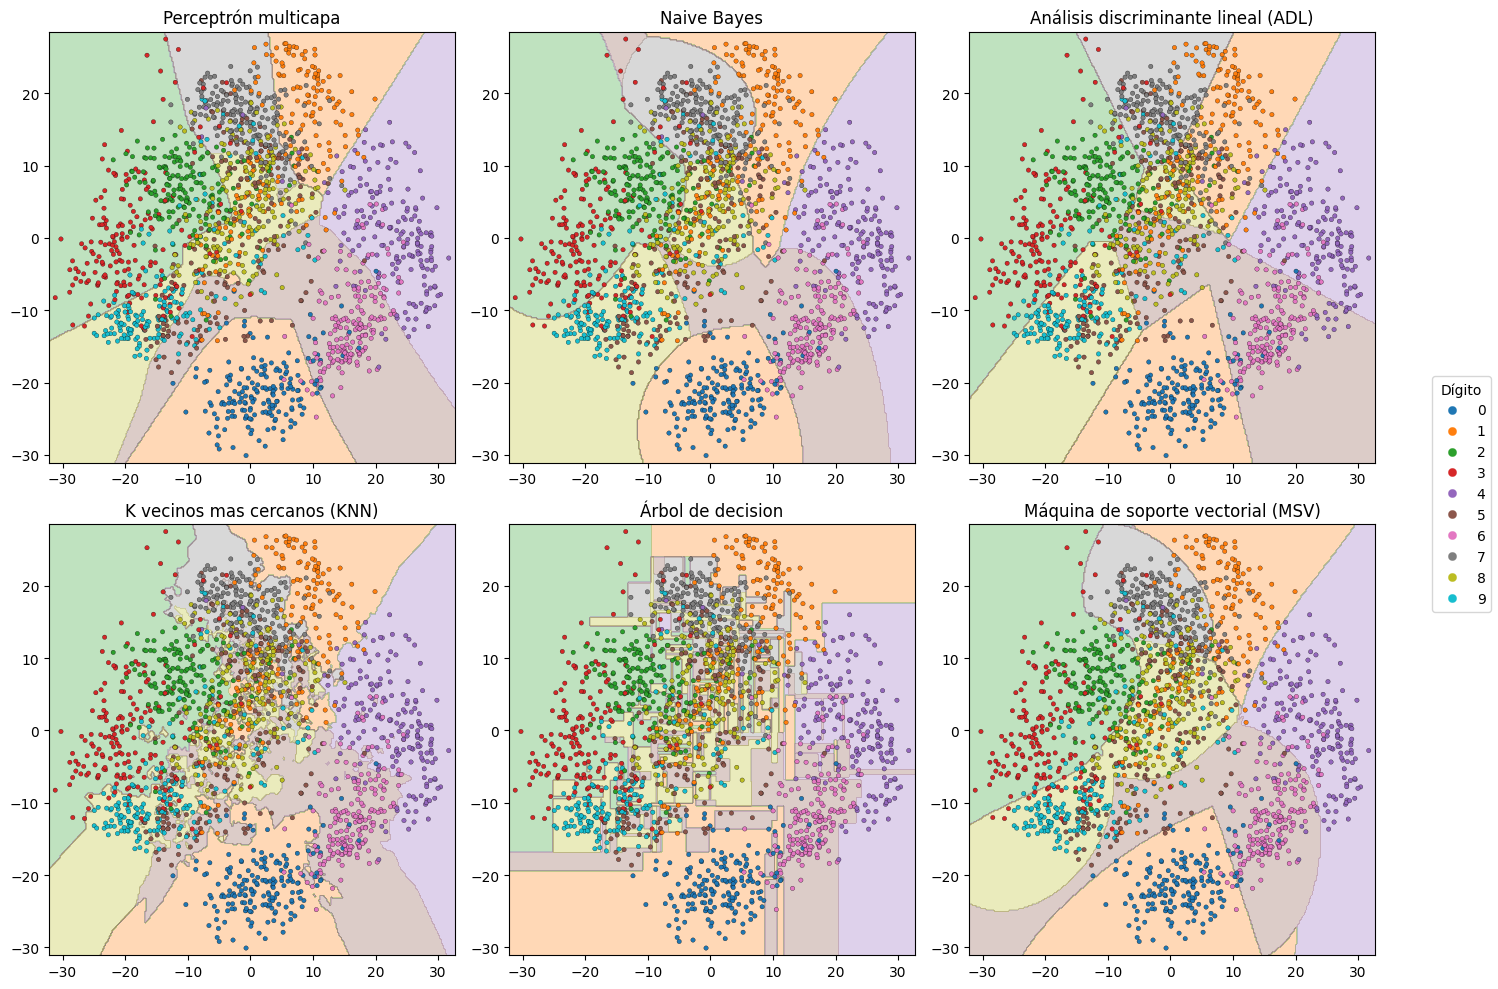

In [13]:
pca = PCA(n_components=2, random_state=2077)
X_2d = pca.fit_transform(X)

x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, nombre_modelo, modelo in zip(axes.ravel(), nombres, modelos):
    modelo_2d = clone(modelo)
    modelo_2d.fit(X_2d, y)

    Z = modelo_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='tab10', vmin=-0.5, vmax=9.5)
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', vmin=-0.5, vmax=9.5, s=10, edgecolors='k', linewidths=0.2)
    ax.set_title(nombre_modelo)

handles, _ = scatter.legend_elements()
fig.legend(handles, digits.target_names, title='Dígito', loc='center right')
plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.show()


## Análisis de resultados – Ejercicio 2

Se comparó el perceptrón multicapa (arquitectura `(50,)` elegida en el Ejercicio 1) con Naive Bayes, ADL, KNN, Árbol de decisión y SVM, usando las mismas 5 particiones de `KFold`. Los resultados, ordenados por media de aciertos, fueron: **SVM (98,78%)**, **KNN (98,61%)**, **MLP (96,99%)**, **ADL (95,05%)**, **Árbol de decisión (86,03%)** y **Naive Bayes (83,08%)**. El MLP no fue el más preciso, pero tuvo la varianza más baja de los seis (0,000023), incluso menor que SVM y KNN, mostrando ser el más estable entre particiones.

### Cómo leer la matriz de confusión

Cada celda `(fila i, columna j)` cuenta cuántas imágenes del dígito `i` el modelo predijo como `j`. La diagonal son los aciertos; todo lo que está fuera de la diagonal es un error específico. Dos cosas para comparar entre modelos: si los errores están **concentrados** en uno o dos pares de dígitos, o **dispersos** en muchos pares distintos (síntoma de que el modelo no entendió bien la estructura general de los datos).

### Cómo leer el gráfico de fronteras de decisión (PCA)

El fondo coloreado es lo que el modelo predeciría en cada zona del plano; los puntos son los datos reales coloreados por su clase verdadera. Un punto de un color sobre un fondo de otro color es un "error" — pero en la proyección a 2D, no en las 64 dimensiones reales (por eso puede no coincidir con la matriz de confusión: acá se comprimen 64 píxeles a solo 2 números, y esa compresión mezcla clases que en 64D están bien separadas). Lo que sí es comparable entre modelos es la **forma** de cada frontera, porque esa forma es la firma geométrica del algoritmo:

- **Naive Bayes** dibuja elipses alineadas a los ejes (su supuesto: cada clase es una campana de Gauss, sin correlación entre variables).
- **Árbol de decisión** dibuja rectángulos en escalones (cada corte es "¿esta variable es mayor o menor a un valor?").
- **ADL** dibuja fronteras rectas (asume que todas las clases comparten la misma forma de dispersión y separa linealmente).
- **KNN** dibuja fronteras irregulares y recortadas (la clase depende de los vecinos más cercanos, sin fórmula global).
- **SVM** dibuja curvas suaves que se adaptan a la forma real de cada grupo (busca el margen óptimo, sin asumir independencia ni una forma fija).
- **MLP** dibuja regiones curvas más flexibles, combinando de forma no lineal las entradas a través de las capas ocultas.

### Por qué cada modelo confunde lo que confunde (con datos reales de la matriz de confusión)

- **Naive Bayes** (304 errores totales, el peor de todos): sus dos supuestos —independencia entre píxeles y distribución gaussiana por píxel— son falsos para imágenes. El resultado es un patrón muy revelador: **decenas de dígitos distintos caen sobre "8" y "7"** (real 2→predicho 8: 44 veces; 1→8: 25; 3→8: 25; 9→8: 23; 4→7: 17; 9→7: 16). No es que confunda pares puntuales difíciles: al ignorar la correlación entre píxeles vecinos, pierde la forma real del trazo y termina "cayendo" sistemáticamente sobre las clases que probabilísticamente resultan más genéricas. Esto es un sesgo del **modelo**, no de los datos.

- **Árbol de decisión** (251 errores): sus cortes rígidos en un solo píxel a la vez generalizan mal cuando dos formas de escribir el mismo dígito activan píxeles distintos. A diferencia de Naive Bayes, sus errores están más repartidos entre pares distintos (4→6: 10, 2→3: 9, 8→9: 9, 8→2: 9, 8→1: 9) — no tiene un cajón "genérico" hacia donde caiga todo, cada error es más una decisión puntual mal tomada.

- **ADL** (89 errores): al forzar fronteras lineales, su mayor confusión es 8→1 (12 veces) y 5→9 (8) — son pares donde una separación curva ayudaría, pero ADL no puede dibujar una.

- **KNN** (25 errores) y **SVM** (22 errores): los dos modelos con menos errores, y ambos muy dispersos (ningún par supera las 6 confusiones). Ninguno asume independencia ni una forma de frontera fija, por eso se adaptan mejor a la variedad real de las 1797 imágenes.

- **MLP** (54 errores): su confusión más repetida también es 8→1 (6 veces).

**El dato más interesante para exponer**: la confusión **"8 confundido con 1"** aparece como top confusión en MLP, ADL, KNN *y* SVM — cuatro modelos con lógicas completamente distintas. Eso sugiere que hay imágenes de "8" en el dataset que son genuinamente ambiguas (un dato del problema, no una falla de un modelo en particular). En cambio, el patrón de Naive Bayes (todo cayendo sobre 8 y 7, con decenas de casos) es propio de *ese* modelo, consecuencia directa de sus supuestos violados — no de que esas imágenes sean difíciles en sí.

### Conclusión

Los modelos que no asumen independencia entre variables ni una forma fija de frontera (SVM, KNN) obtuvieron el mejor desempeño en Digits, donde la información relevante está en la correlación espacial entre píxeles vecinos. El MLP, si bien no fue el más preciso, fue el más estable entre particiones. Naive Bayes fue el peor por lejos, y la matriz de confusión lo confirma con evidencia concreta: sus errores no son casos difíciles puntuales, sino un sesgo sistemático hacia predecir "8" y "7" que se explica directamente por sus supuestos de independencia y normalidad, ambos falsos para datos de imagen.


## Ejercicio 3

Utilizando las funciones provistas por Scikit-learn, implemente los métodos de ensambles de clasificadores **Bagging** y **AdaBoost**. Compare el desempeño de estos modelos empleando 5 particiones con el conjunto de datos **Wine**.

Bagging: Es un panel de catadores independientes que evalúan distintas muestras de la bodega al mismo tiempo y deciden la clase del vino por mayoría simple para evitar sesgos.

AdaBoost: Es una cadena de catadores donde cada uno se obsesiona exclusivamente con corregir los vinos que el anterior clasificó mal, dándole el voto decisivo a los más precisos.



Bagging (El panel de cata independiente)

Si le das las 178 botellas y la lista completa de los 13 atributos químicos a los 100 catadores a la vez, todos van a terminar mirando lo mismo (por ejemplo, todos se van a fijar solo en el alcohol y la color_intensity) y se van a equivocar en los mismos vinos.

Para evitar eso, usás el método Bagging: a cada catador le armás un lote de botellas aleatorio (algunas se repiten, otras faltan) y le escondés algunos atributos. A uno le das los datos de los flavanoids y el malic_acid; a otro, la alcalinity_of_ash y la cantidad de proline.

    Cómo trabajan: Todos los catadores analizan sus botellas al mismo tiempo, en habitaciones separadas. No hablan entre ellos.

    Cómo deciden: Cuando entra a la bodega una botella misteriosa nueva, se la das a los 100. Cada uno mira su machete, analiza los atributos que conoce y dice: "Para mí es de la clase_1". Se vota por mayoría simple. Si 70 dicen clase_1, la botella es clase_1.

    Para qué sirve en la práctica: Evita que el panel se memorice las botellas exactas de la bodega y se enceguezca por un solo atributo. Logra un consenso mucho más robusto frente a vinos nuevos.

AdaBoost (El entrenamiento escalonado para vinos difíciles)

Acá la dinámica cambia. En vez de poner a todos a la vez, hacés pasar a los catadores de a uno. Estos catadores son novatos (modelos "débiles") y solo saben hacer reglas muy básicas, como "si tiene más de 13 de alcohol, es clase_0".

    Cómo trabajan: Pasa el Catador #1 e intenta clasificar las 178 botellas. Acertará en los vinos fáciles (las 59 botellas de la clase_0 que suelen estar muy marcadas), pero se va a confundir con los vinos engañosos, cruzando botellas de la clase_1 y clase_2.
    A esas botellas donde el Catador #1 metió la pata, les pegás una etiqueta roja gigante.
    Pasa el Catador #2 y le decís: "Mirá los datos que quieras, pero tu vida depende de clasificar bien las botellas de etiqueta roja". Este se enfocará en buscar atributos que destraben ese problema (quizás el hue o los total_phenols). Seguramente arregle el problema, pero falle en otras botellas nuevas. A esas nuevas fallas les ponés etiqueta roja, y pasa el Catador #3. Así sucesivamente. Trabajan en serie.

    Cómo deciden: Al final, para clasificar un vino nuevo, todos votan. Pero a diferencia del Bagging, el voto no vale lo mismo. El catador que resultó ser un experto con altísima precisión global tiene un voto ponderado que pesa mucho más en la decisión final que el de un catador que se equivocó un montón.

    Para qué sirve en la práctica: Transforma a un equipo de novatos en un "Súper Sommelier", obligando al modelo a obsesionarse con aprender a distinguir esos vinos que están justo en la frontera entre una clase y otra.

### Presentación del dataset

Antes de comparar los ensambles, veamos qué estamos clasificando: **Wine** contiene el análisis químico de 178 vinos provenientes de 3 variedades de uva distintas cultivadas en la misma región de Italia. El objetivo es predecir la variedad (`class_0`, `class_1`, `class_2`) a partir de 13 mediciones químicas (alcohol, ácido málico, magnesio, fenoles, color, etc.).


In [14]:
wine = load_wine()

X = wine.data
y = wine.target

resumen_wine = pd.DataFrame({
    'Clase': wine.target_names,
    'Muestras': np.bincount(wine.target),
}).set_index('Clase')

display(resumen_wine)

print("Atributos utilizados:", list(wine.feature_names))

,Muestras
Clase,
class_0,59
class_1,71
class_2,48


Atributos utilizados: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


### Comparación de Bagging y AdaBoost (KFold = 5)

Se evalúan ambos ensambles sobre las mismas 5 particiones de `KFold`, para que la comparación sea justa.


,Particiones,Mínimo (%),Máximo (%),Media (%),Varianza
Modelo,,,,,
Bagging,5,94.44,97.22,96.63,0.000120
AdaBoost,5,88.57,100.00,95.48,0.001501


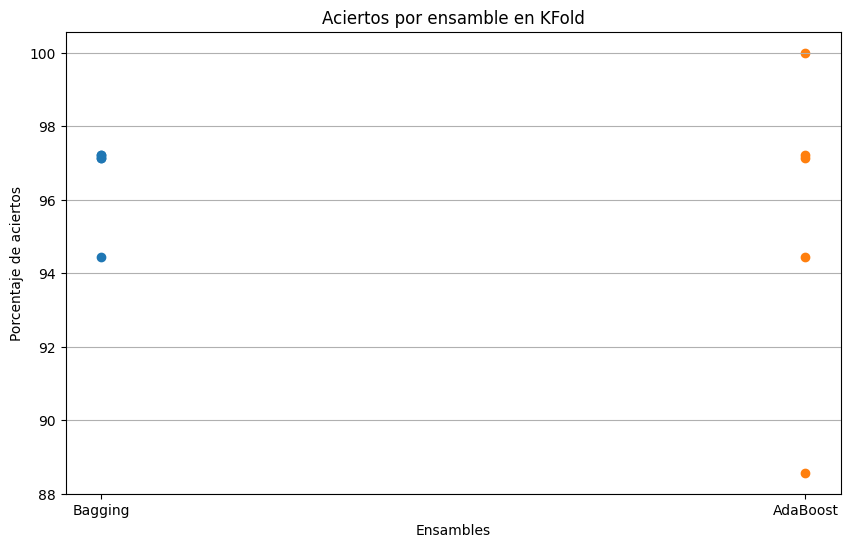

In [15]:
nombres = ['Bagging', 'AdaBoost']

modelos = [BaggingClassifier(random_state=2077), AdaBoostClassifier(random_state=2077)]

datos = []
for i in range(len(nombres)):
    resultados = evaluar_kfold(5, modelos[i])
    datos.append(resultados)

tabla_ex3 = resultados_a_df(nombres, datos)
display(tabla_ex3)

graficar(nombres, datos, titulo='Aciertos por ensamble en KFold', xlabel='Ensambles')

### Matrices de confusión

Al igual que en el Ejercicio 2, se calculan las matrices de confusión de Bagging y AdaBoost sobre las mismas particiones de `KFold`, para ver si los errores de cada ensamble se concentran en las mismas muestras o se distribuyen distinto.


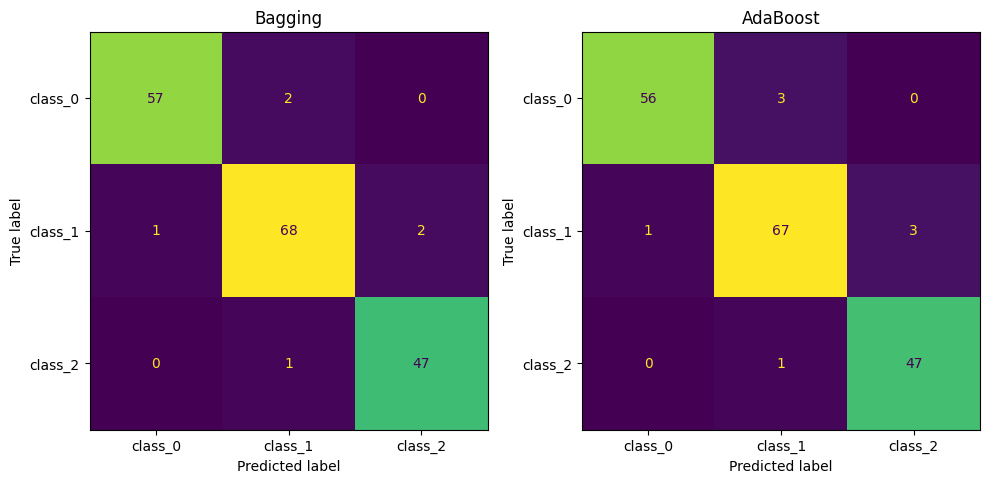

In [16]:
kf_ex3 = KFold(n_splits=5, shuffle=True, random_state=2077)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, nombre_modelo, modelo in zip(axes, nombres, modelos):
    predicciones = cross_val_predict(modelo, X, y, cv=kf_ex3)
    matriz = confusion_matrix(y, predicciones)
    ConfusionMatrixDisplay(matriz, display_labels=wine.target_names).plot(ax=ax, colorbar=False)
    ax.set_title(nombre_modelo)

plt.tight_layout()
plt.show()


### Importancia de atributos

¿En qué atributos químicos se apoya cada ensamble para decidir la variedad de vino? Se reentrena una copia de cada modelo sobre el dataset completo y se comparan sus `feature_importances_`.


,Bagging,AdaBoost
proline,0.357,0.118
flavanoids,0.313,0.337
color_intensity,0.155,0.081
alcohol,0.060,0.070
od280/od315_of_diluted_wines,0.049,0.183
hue,0.032,0.067
total_phenols,0.012,0.000
alcalinity_of_ash,0.009,0.000
proanthocyanins,0.005,0.000
magnesium,0.003,0.000


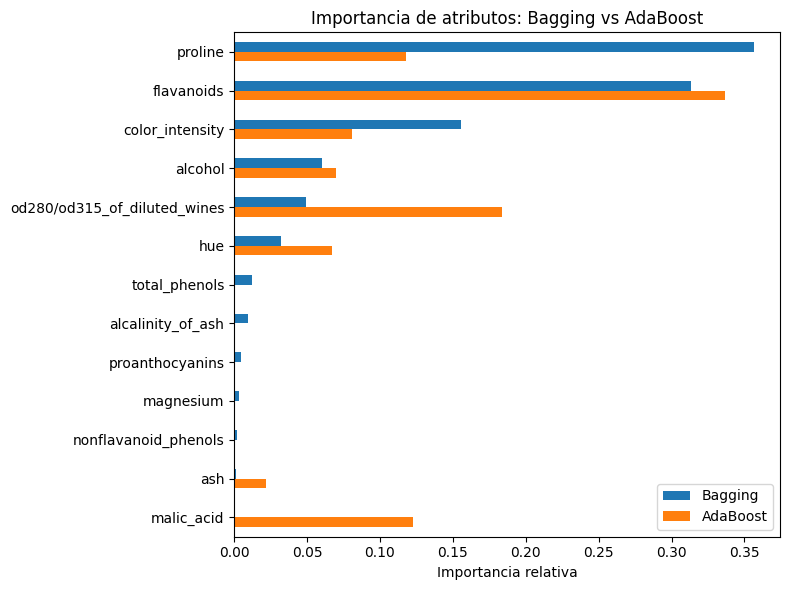

In [17]:
modelo_bagging_full = clone(modelos[0]).fit(X, y)
modelo_adaboost_full = clone(modelos[1]).fit(X, y)

importancia_bagging = np.mean([arbol.feature_importances_ for arbol in modelo_bagging_full.estimators_], axis=0)
importancia_adaboost = modelo_adaboost_full.feature_importances_

tabla_importancias = pd.DataFrame({
    'Bagging': importancia_bagging,
    'AdaBoost': importancia_adaboost,
}, index=wine.feature_names).sort_values('Bagging', ascending=False)

display(tabla_importancias.style.format('{:.3f}').background_gradient(cmap='Greens'))

tabla_importancias.plot(kind='barh', figsize=(8, 6))
plt.xlabel('Importancia relativa')
plt.title('Importancia de atributos: Bagging vs AdaBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Análisis de resultados – Ejercicio 3

Se compararon Bagging y AdaBoost sobre el dataset Wine (178 muestras de 3 variedades de uva, descriptas con 13 atributos químicos) usando 5 particiones de KFold.

El modelo **Bagging** obtuvo porcentajes de aciertos entre **94,44% y 97,22%**, con una media de **96,63%** y una varianza de **0,0001201**. Por otro lado, **AdaBoost** obtuvo resultados entre **88,57% y 100%**, con una media de **95,48%** y una varianza de **0,0015006** — unas 12 veces mayor que la de Bagging.

Para entender esa diferencia se calcularon las matrices de confusión de ambos modelos sobre las mismas particiones. Los resultados agregados fueron muy parecidos: Bagging cometió 6 errores en total (sobre 178 muestras) y AdaBoost cometió 8, y en ambos casos los errores se concentraron en los mismos lugares — confusiones entre `class_0`↔`class_1` y `class_1`↔`class_2`, nunca entre `class_0` y `class_2` (las variedades más distintas entre sí). Es decir, en conjunto ambos modelos clasifican de forma parecida y cometen el mismo tipo de error — pero esa matriz, al sumar las 5 particiones en una sola cuenta, no muestra la inestabilidad partición por partición que sí revela la varianza de la tabla.

Esa diferencia se explica por cómo funciona cada método. **Bagging** entrena varios árboles de forma independiente, cada uno sobre una muestra aleatoria (bootstrap) del dataset, y promedia sus votos — promediar modelos independientes reduce la varianza casi por construcción. **AdaBoost**, en cambio, entrena los árboles en secuencia, y cada uno se enfoca más en las muestras que el anterior clasificó mal. Con un dataset chico como Wine (unas 35 muestras por partición de test), una sola muestra atípica mal clasificada puede pesar mucho en las iteraciones siguientes, haciendo que el resultado final dependa más de qué muestras específicas cayeron en cada partición — de ahí la varianza mucho mayor entre particiones, aunque el total de errores acumulados sea parecido al de Bagging.

Esto se confirma mirando qué atributos usa cada modelo: ambos coinciden en que `proline` y `flavanoids` son los más determinantes, pero AdaBoost ignora por completo 5 de los 13 atributos químicos (su importancia es 0 en `total_phenols`, `alcalinity_of_ash`, `proanthocyanins`, `magnesium` y `nonflavanoid_phenols`), porque su clasificador base (un *stump*, un árbol de un solo corte) solo puede usar un atributo por ronda de boosting. Bagging, en cambio, usa árboles completos que reparten la decisión entre los 13 atributos. Esta dependencia de AdaBoost en un conjunto más chico de atributos (por ejemplo, le da bastante peso a `malic_acid`, que Bagging ignora totalmente) es consistente con su mayor varianza: al apoyarse en menos información, es más sensible a cómo se distribuyen las muestras en cada partición.

En conclusión, Bagging obtuvo un mejor resultado promedio y, sobre todo, mucho más estable entre particiones que AdaBoost. La razón no es que AdaBoost clasifique peor en general (las matrices de confusión son casi idénticas), sino que su mecanismo de reponderación secuencial, apoyado en muy pocos atributos, lo hace más sensible a qué muestras específicas caen en cada partición de entrenamiento y prueba.
